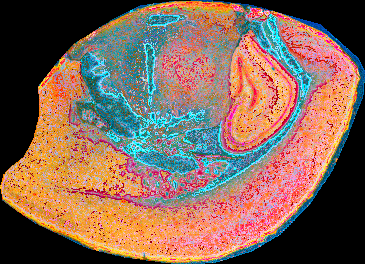

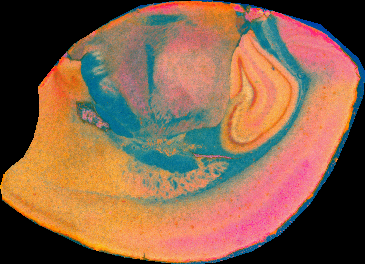

In [30]:
import glob
import cv2
import numpy as np
from PIL import Image
import torch

# Compute gradient magnitude for each image
# Multi-scale gradient computation
def compute_gradient(img):
    #scales = [1, 9, 15]  # Different Sobel kernel sizes for multi-scale gradients
    scales = [3]
    gradient_magnitude = np.zeros_like(img, dtype=np.float64)

    for ksize in scales:
        grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=ksize)
        grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=ksize)
        grad_mag = np.sqrt(grad_x**2 + grad_y**2)
        gradient_magnitude += grad_mag  # Sum multi-scale gradients

    return gradient_magnitude


#paths = glob.glob("correlation3 NRL4509-s16-r4/*.png")
paths = glob.glob("correlation4/*.png")
images = []
for path in paths:
    #display(Image.open(path))
    images.append(np.array(Image.open(path)))


gradients = [compute_gradient(img).max(axis=-1) for img in images]


# Normalize gradients to use as weights
#gradients = [cv2.normalize(g, None, 0, 1, cv2.NORM_MINMAX)[:, :, None] for g in gradients]
gradients = np.float32(gradients)
gradients = torch.nn.Softmax(dim=0)(torch.from_numpy(gradients * 1)).numpy()[:, :, :, None]

# Compute weighted sum of images
weighted_sum = np.zeros_like(images[0], dtype=np.float64)
total_weight = np.zeros_like(images[0], dtype=np.float64)
for img, weight in zip(images, gradients):
    weighted_sum += img * weight
    total_weight += weight
# Avoid division by zero


blended_image = (weighted_sum / (1e-4 + total_weight))
blended_image = np.uint8(blended_image)
display(Image.fromarray(blended_image))
display(Image.fromarray(np.uint8(np.mean(images, axis=0))))
# for path in paths:
#     display(Image.open(path))


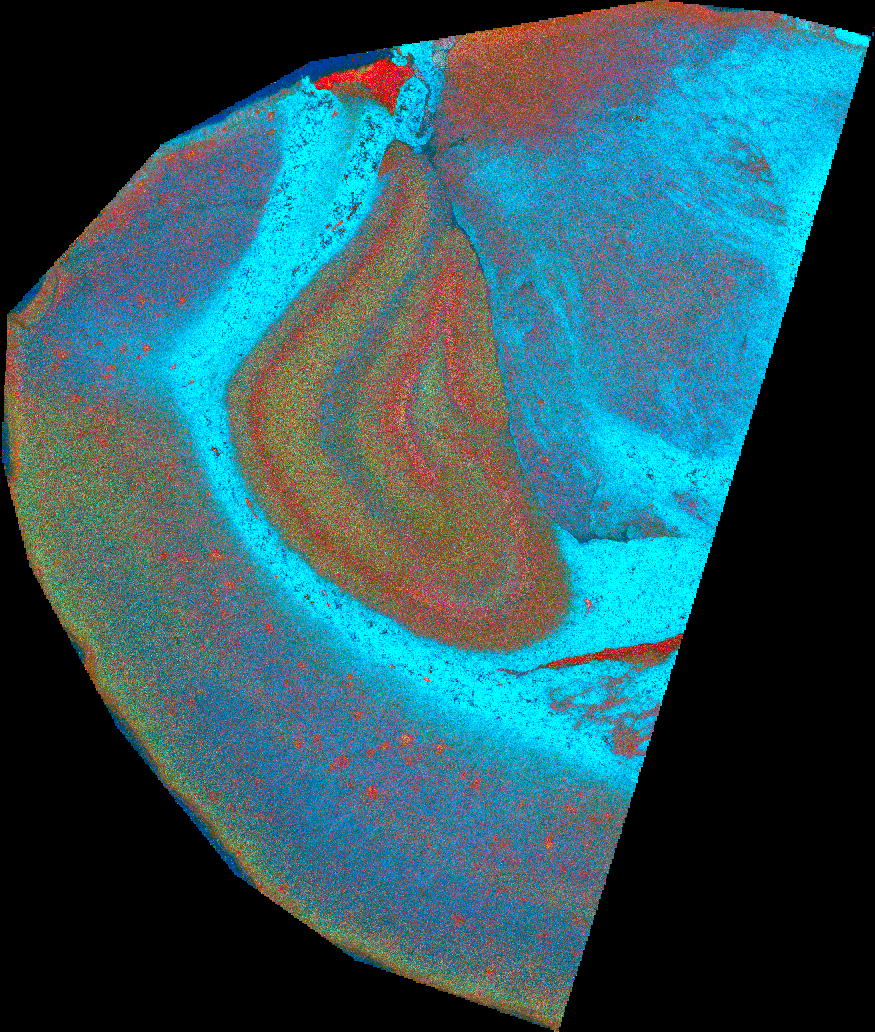

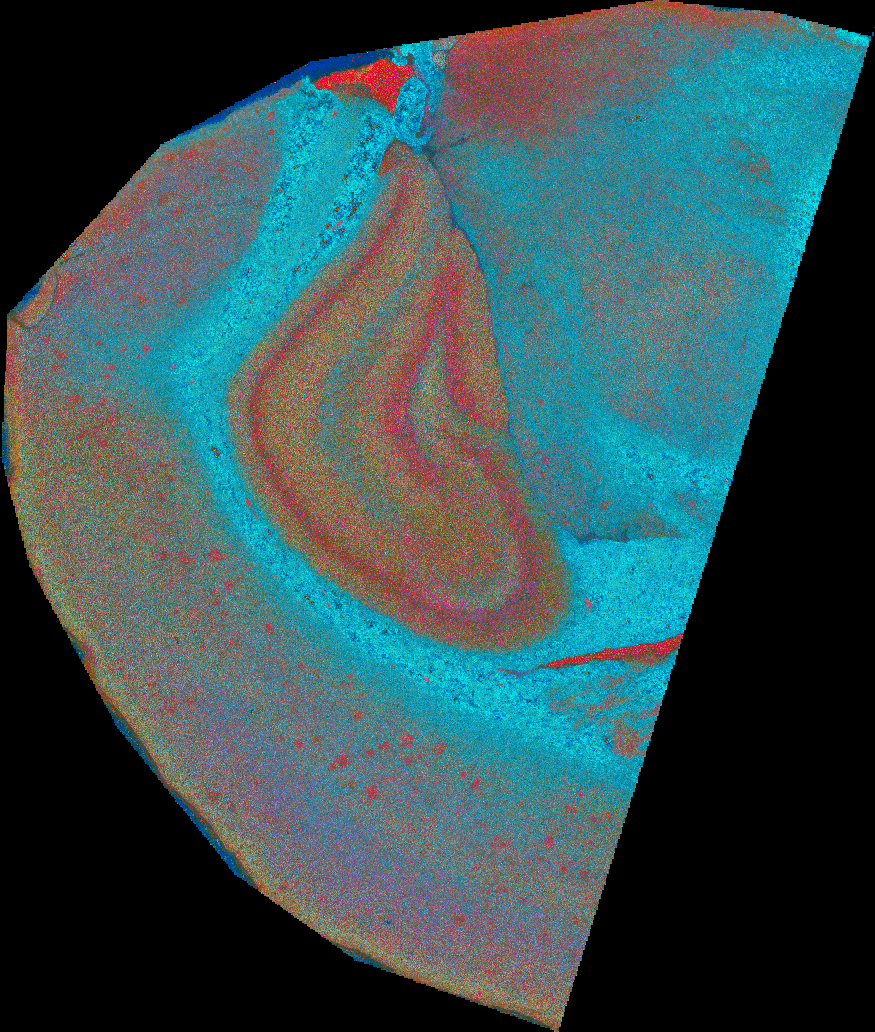

In [67]:
import cv2
import numpy as np
import glob
from sklearn.mixture import GaussianMixture
from PIL import Image

import cv2
import numpy as np

def blend_images_mean_shift(image_list, sp=15, sr=0):
    """
    Applies pyrMeanShiftFiltering to each image in the list and blends them by averaging.

    Parameters:
    - image_list: list of np.ndarray, each of shape (H, W, 3), containing RGB images.
    - sp: int, spatial window radius for mean shift filtering.
    - sr: int, color window radius for mean shift filtering.

    Returns:
    - blended_image: np.ndarray, the final blended RGB image.
    """
    if not image_list:
        raise ValueError("The image list is empty.")

    # Convert images to OpenCV format (uint8)
    filtered_images = []


    # Process images in groups of 3
    reds, greens, blues = [], [], []
    for i in range(0, len(image_list), 3):
        group = image_list[i:i+3]
        # If last group has fewer than 3 images, pad with copies of last image
        while len(group) < 3:
            group.append(group[-1])
        
        red = cv2.merge([g[:, :, 0] for g in group])
        green = cv2.merge([g[:, :, 1] for g in group])
        blue = cv2.merge([g[:, :, 2] for g in group])
        
        red = cv2.pyrMeanShiftFiltering(red, sp, sr)
        green = cv2.pyrMeanShiftFiltering(green, sp, sr)
        blue = cv2.pyrMeanShiftFiltering(blue, sp, sr)

        reds.append(red)
        greens.append(green)
        blues.append(blue)

    print(np.array(reds).shape)

    r, g, b = np.mean(reds, axis=(0, 3)), np.mean(greens, axis=(0, 3)), np.mean(blues, axis=(0, 3))
    r = np.clip(r, 0, 255).astype(np.uint8)
    g = np.clip(g, 0, 255).astype(np.uint8)
    b = np.clip(b, 0, 255).astype(np.uint8)
    blended_image = cv2.merge([r, g, b])

    return blended_image

#paths = glob.glob(r"correlation3 NRL4509-s16-r4/*.png")
paths = glob.glob(r"correlation7/*.png")
#paths = glob.glob(r"C:\Users\PahnkeLab\Desktop\Maldi_MSI\notebooks\correlation1 NRL4485-s2\2_*.png")

images = []
for path in paths:
    a = np.array(Image.open(path))
    images.append(a)

res = np.uint8(np.median(images, axis=0))
display(Image.fromarray(res))

res = np.uint8(np.mean(images, axis=0))
display(Image.fromarray(res))

# res = blend_images_mean_shift(images, sp=20, sr=20)
# display(Image.fromarray(res))

for g in gradients:
    display(Image.fromarray(np.uint8(255 * g)))

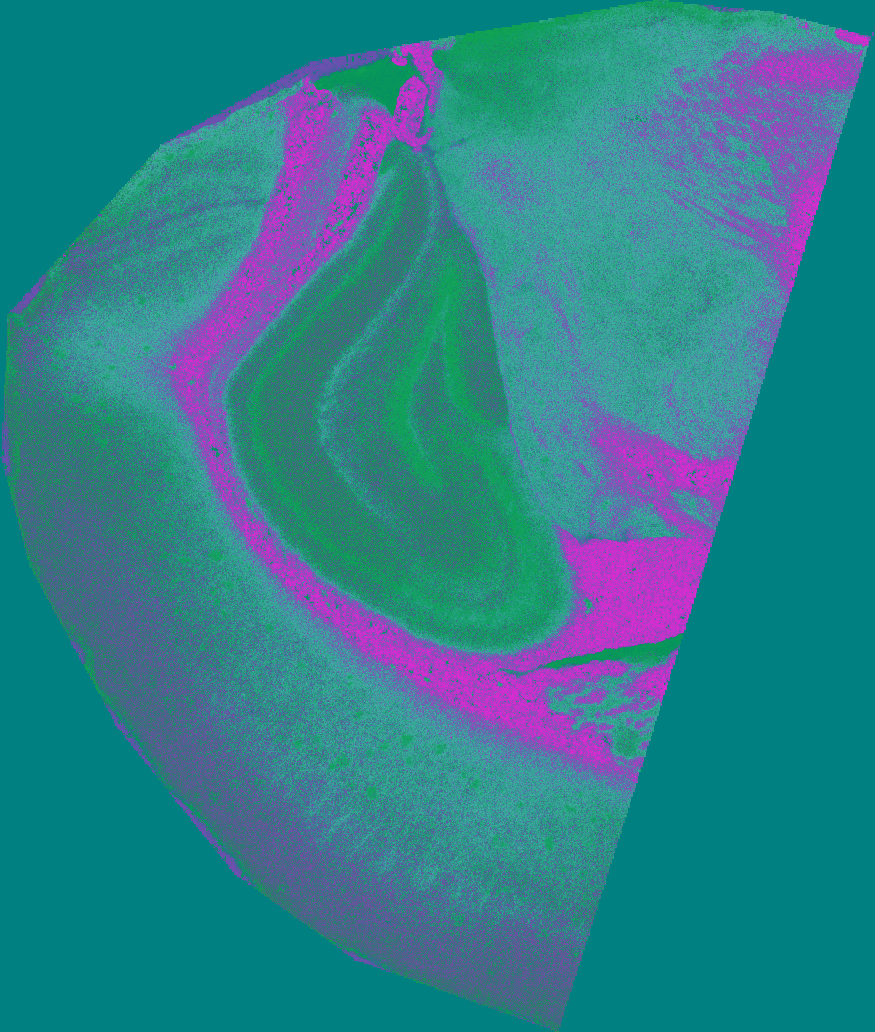

In [22]:
display(Image.fromarray(cv2.cvtColor(merged_image, cv2.COLOR_RGB2Lab)))

In [23]:
res.dtype

dtype('uint8')